In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

df = pd.read_csv('cardio_data.csv', sep=';')
print(df.shape)
df.head()

(70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0
smoke,70000.0,0.088129,0.283484,0.0,0.00,0.0,0.00,1.0


In [6]:
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows: 0


In [9]:
df['age_years'] = (df['age'] / 365.25).round(1)

df = df[(df['ap_hi'] > 0) & (df['ap_lo'] > 0)]
df = df[df['ap_lo'] <= df['ap_hi']]

for col in ['ap_hi', 'ap_lo', 'height', 'weight']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df = df[(df[col] >= lower) & (df[col] <= upper)]

df = df.drop(columns=['id'])

df['bmi'] = (df['weight'] / ((df['height'] / 100) ** 2)).round(1)

print(df.shape)
df.head()

(65250, 14)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi
0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.4,22.0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.9
2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.5
3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.7
4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.0


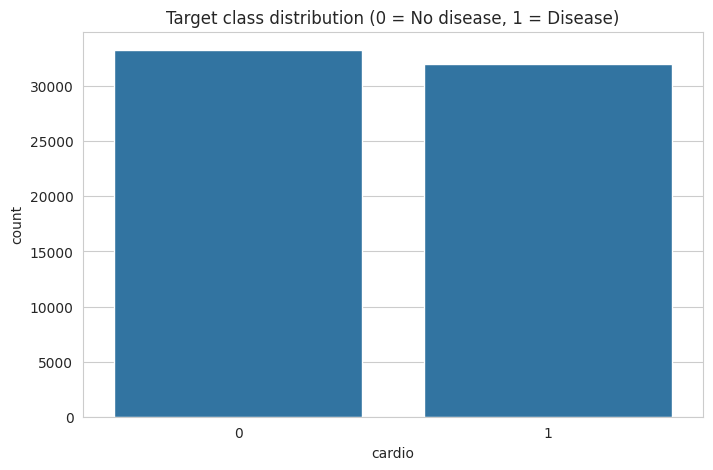

cardio
0    0.509839
1    0.490161
Name: proportion, dtype: float64


In [10]:
sns.countplot(x='cardio', data=df)
plt.title('Target class distribution (0 = No disease, 1 = Disease)')
plt.show()

print(df['cardio'].value_counts(normalize=True))

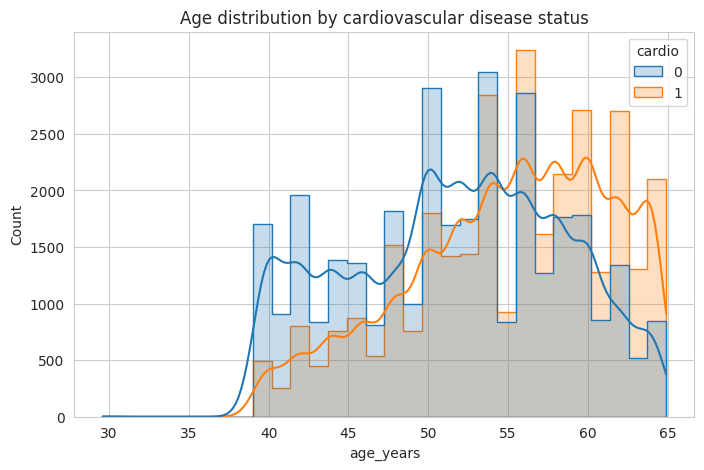

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='age_years', hue='cardio', bins=30, kde=True, element='step')
plt.title('Age distribution by cardiovascular disease status')
plt.show()

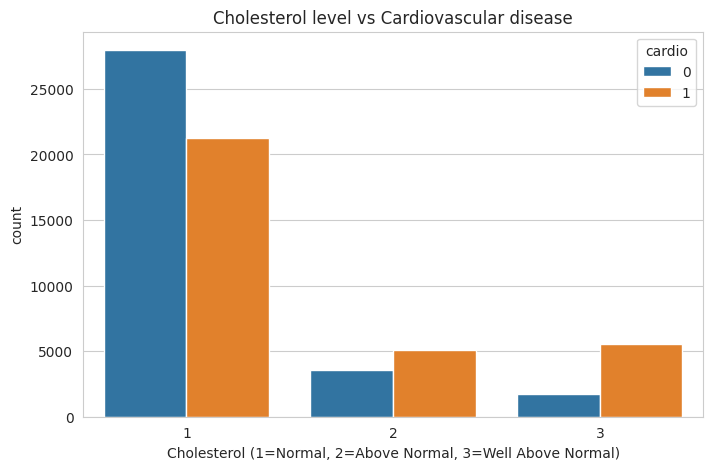

In [12]:
sns.countplot(x='cholesterol', hue='cardio', data=df)
plt.title('Cholesterol level vs Cardiovascular disease')
plt.xlabel('Cholesterol (1=Normal, 2=Above Normal, 3=Well Above Normal)')
plt.show()

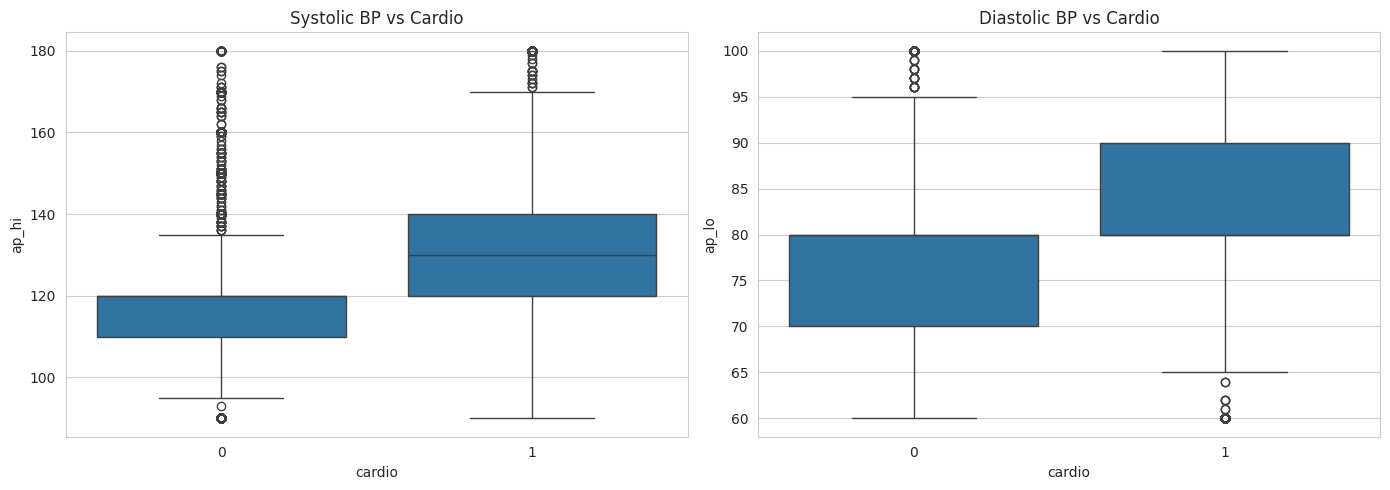

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.boxplot(x='cardio', y='ap_hi', data=df, ax=axes[0])
axes[0].set_title('Systolic BP vs Cardio')
sns.boxplot(x='cardio', y='ap_lo', data=df, ax=axes[1])
axes[1].set_title('Diastolic BP vs Cardio')
plt.tight_layout()
plt.show()

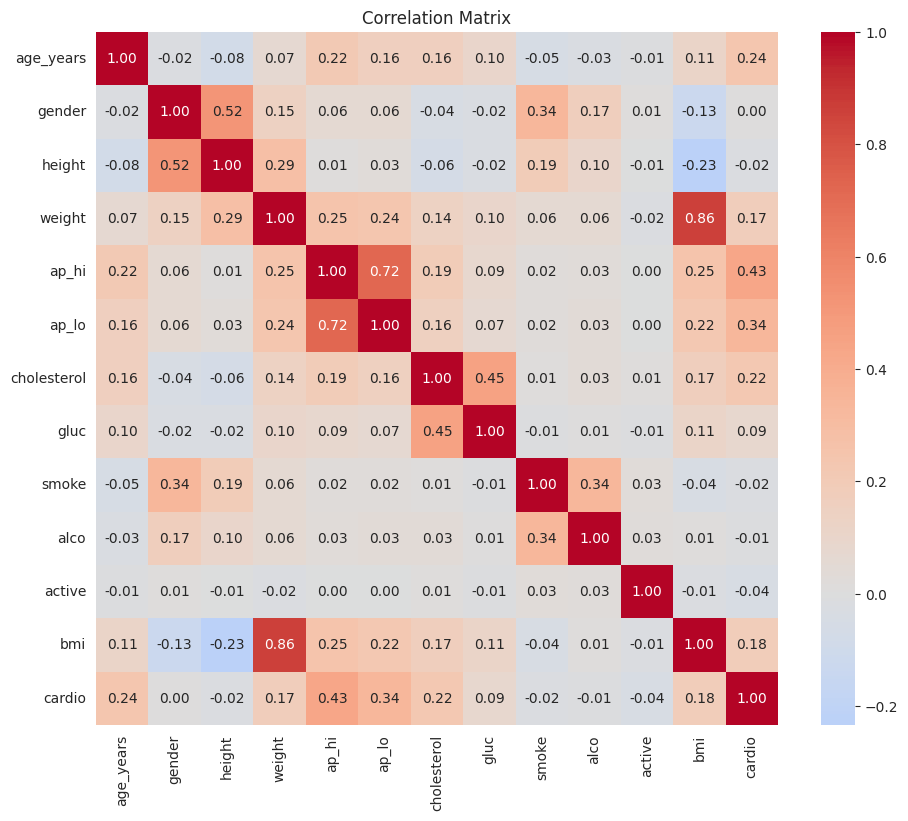

In [14]:
corr_cols = ['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
             'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi', 'cardio']

plt.figure(figsize=(11, 9))
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [15]:
print(corr['cardio'].sort_values(ascending=False))

cardio         1.000000
ap_hi          0.432290
ap_lo          0.339638
age_years      0.242385
cholesterol    0.219628
bmi            0.184900
weight         0.173741
gluc           0.087559
gender         0.003034
alco          -0.010492
height        -0.018489
smoke         -0.019230
active        -0.037827
Name: cardio, dtype: float64


In [16]:
X = df.drop(columns=['cardio', 'age'])  # raw 'age' (days) drop, age_years keep
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(52200, 12) (13050, 12)


In [17]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15),
    'Decision Tree': DecisionTreeClassifier(max_depth=8, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
}

results = []

rng = np.random.RandomState(42)
svm_idx = rng.choice(X_train_scaled.shape[0], size=8000, replace=False)
X_train_svm = X_train_scaled[svm_idx]
y_train_svm = y_train.iloc[svm_idx]

for name, model in models.items():
    if name == 'SVM':
        model.fit(X_train_svm, y_train_svm)
    else:
        model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    results.append({'Model': name, 'Accuracy': acc, 'ROC-AUC': auc})
    print(f"{name}: Accuracy = {acc:.4f}, ROC-AUC = {auc:.4f}")

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
results_df

Logistic Regression: Accuracy = 0.7243, ROC-AUC = 0.7869
KNN: Accuracy = 0.7155, ROC-AUC = 0.7741
Decision Tree: Accuracy = 0.7275, ROC-AUC = 0.7872
SVM: Accuracy = 0.7244, ROC-AUC = 0.7834
Random Forest: Accuracy = 0.7280, ROC-AUC = 0.7958


,Model,Accuracy,ROC-AUC
0,Random Forest,0.728046,0.795813
1,Decision Tree,0.727510,0.787201
2,SVM,0.724444,0.783406
3,Logistic Regression,0.724291,0.786920
4,KNN,0.715479,0.774096


              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6653
           1       0.75      0.66      0.71      6397

    accuracy                           0.73     13050
   macro avg       0.73      0.73      0.73     13050
weighted avg       0.73      0.73      0.73     13050



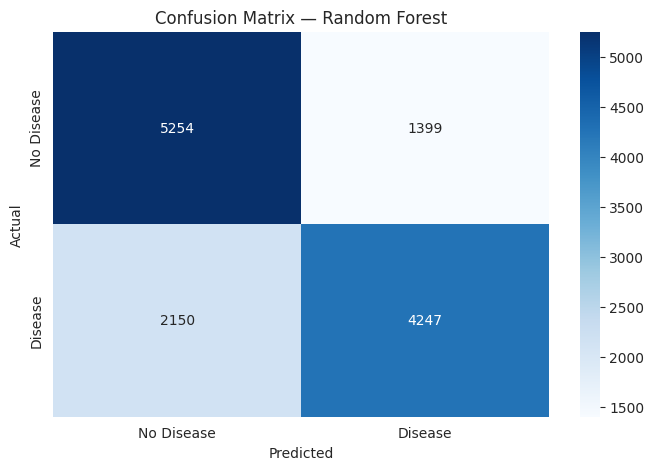

In [18]:
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

/tmp/ipykernel_1200/3203432968.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='mako')


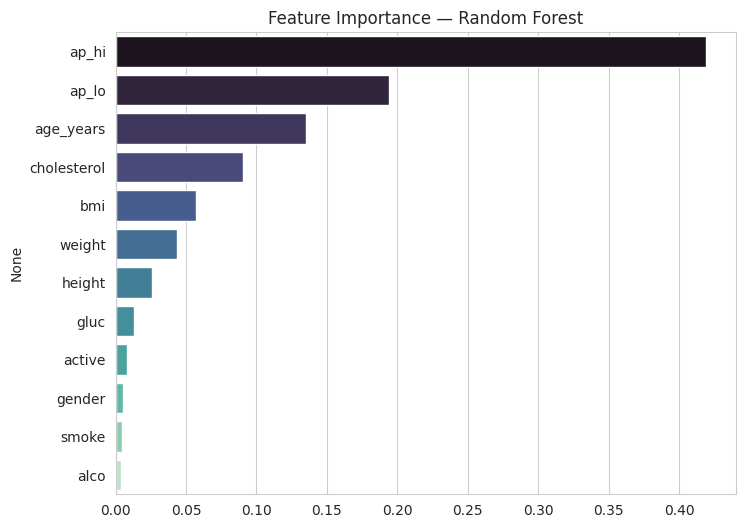

ap_hi          0.419188
ap_lo          0.193883
age_years      0.134929
cholesterol    0.090418
bmi            0.056883
weight         0.043663
height         0.025780
gluc           0.013351
active         0.008157
gender         0.005099
smoke          0.004823
alco           0.003827
dtype: float64


In [19]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title('Feature Importance — Random Forest')
plt.show()
print(importances)